## Metric Meaning (Quick)

- **Accuracy**: overall fraction of correct predictions.
- **Macro-F1**: average F1 across classes, each class gets equal weight.
  This is important when you want fair performance across all activities.
- **Weighted-F1**: class-wise F1 weighted by number of samples in each class.

So when you saw:
- Accuracy = 0.8750
- Macro-F1 = 0.8730
- Weighted-F1 = 0.8730

it means the model is both accurate overall and fairly balanced across classes.

# Single Activity Classification from Range-Doppler CSV

This notebook is for **Single Activity Data** under `Research Data/Single Activity Data` only.

Workflow:
1. Load and inspect data dimensionality by activity and sample.
2. Create a **sample-level split**: 60% train (3 samples) and 40% test (2 samples) per activity.
3. Build and train two models for activity recognition:
   - **CNN** (spatial model on aggregated range-doppler map)
   - **LSTM** (temporal model on frame sequence)
4. Show results:
   - loss/accuracy curves
   - confusion matrix
   - classification report

Notes:
- The feature design is inspired by common mmWave micro-Doppler / range-Doppler processing pipelines.
- If TensorFlow is missing, install it in your environment before training.

In [22]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import zoom

from sklearn.metrics import confusion_matrix, classification_report

# Try TensorFlow/Keras for CNN + LSTM
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except Exception as e:
    raise ImportError(
        "TensorFlow is required. Install with: pip install tensorflow\n"
        f"Original import error: {e}"
    )

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

DATA_ROOT = Path.cwd() / "Research Data" / "Single Activity Data"
EXPECTED_ACTIVITIES = ["Sitting", "Standing", "Waiving", "Walking"]

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_ROOT}")

print("Using data root:", DATA_ROOT)

Using data root: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Research Data\Single Activity Data


In [23]:
REQ = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]


def read_longform(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if all(c in df.columns for c in REQ):
        out = df[REQ].copy()
    else:
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", *REQ]
        elif raw.shape[1] == 4:
            raw.columns = REQ
        else:
            raise ValueError(f"Unsupported format: {csv_path}")
        out = raw[REQ].copy()

    out[REQ] = out[REQ].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=REQ)
    out["frame_number"] = out["frame_number"].astype(np.int64)
    out["range_bin"] = out["range_bin"].astype(np.int64)
    out["doppler_bin"] = out["doppler_bin"].astype(np.int64)
    out["signal_strength"] = out["signal_strength"].astype(np.float32)
    return out


def dataframe_to_cube(df: pd.DataFrame) -> np.ndarray:
    max_r = int(df["range_bin"].max())
    max_d = int(df["doppler_bin"].max())
    r_bins, d_bins = max_r + 1, max_d + 1

    frames = []
    for _, g in df.groupby("frame_number", sort=True):
        m = np.zeros((r_bins, d_bins), dtype=np.float32)
        r = g["range_bin"].to_numpy(dtype=np.int32)
        d = g["doppler_bin"].to_numpy(dtype=np.int32)
        s = g["signal_strength"].to_numpy(dtype=np.float32)
        m[r, d] = s
        frames.append(m)

    return np.stack(frames, axis=0) if frames else np.empty((0, r_bins, d_bins), dtype=np.float32)


def parse_distance(sample_name: str) -> tuple[str, float]:
    # Handles names like 1m, 2m, 2.5, 4.m
    s = sample_name.strip().lower().replace(" ", "")
    cleaned = s.replace("m", "")
    cleaned = cleaned.replace("..", ".")
    if cleaned.endswith("."):
        cleaned = cleaned[:-1]
    try:
        val = float(cleaned)
        return f"{val:g}m", val
    except Exception:
        return sample_name, np.nan


def scan_single_activity_data(root: Path, expected_activities: list[str]) -> pd.DataFrame:
    rows = []
    for activity in expected_activities:
        act_dir = root / activity
        if not act_dir.exists():
            print(f"Warning: activity folder missing: {act_dir}")
            continue

        sample_dirs = sorted([d for d in act_dir.iterdir() if d.is_dir()])
        sample_dirs = [d for d in sample_dirs if (d / "range_doppler.csv").exists()]

        if len(sample_dirs) < 5:
            print(f"Warning: {activity} has {len(sample_dirs)} samples with range_doppler.csv (expected 5)")

        for sample_dir in sample_dirs[:5]:
            csv_path = sample_dir / "range_doppler.csv"
            df = read_longform(csv_path)
            distance_label, distance_m = parse_distance(sample_dir.name)
            rows.append(
                {
                    "activity": activity,
                    "distance": distance_label,
                    "distance_m": distance_m,
                    "sample_name": sample_dir.name,
                    "csv_path": csv_path,
                    "rd_points": len(df),
                    "n_frames": int(df["frame_number"].nunique()),
                }
            )

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError("No valid samples found in Single Activity Data")

    return meta.sort_values(["activity", "distance_m", "sample_name"], na_position="last").reset_index(drop=True)


def split_by_sample(meta: pd.DataFrame) -> pd.DataFrame:
    split_meta = meta.copy()
    split_meta["split"] = ""

    for activity, g in split_meta.groupby("activity"):
        g_sorted = g.sort_values(["distance_m", "sample_name"], na_position="last")
        # 3 train (60%), 2 test (40%) for 5 samples
        train_idx = g_sorted.index[:3]
        test_idx = g_sorted.index[3:5]
        split_meta.loc[train_idx, "split"] = "train"
        split_meta.loc[test_idx, "split"] = "test"

    if (split_meta["split"] == "").any():
        raise RuntimeError("Split assignment failed for some samples")

    return split_meta


meta = scan_single_activity_data(DATA_ROOT, EXPECTED_ACTIVITIES)
split_meta = split_by_sample(meta)

# User-facing dimensionality table with requested columns
class_to_id = {a: i for i, a in enumerate(EXPECTED_ACTIVITIES)}
split_meta_view = split_meta.copy()
split_meta_view["target_class_id"] = split_meta_view["activity"].map(class_to_id)
split_meta_view = split_meta_view.rename(
    columns={
        "activity": "Activity",
        "distance": "Distance",
        "n_frames": "Frames",
        "rd_points": "RD_Points",
        "split": "Split",
        "target_class_id": "Target_Class_ID",
    }
)

split_meta_view = split_meta_view[[
    "Activity",
    "Distance",
    "Frames",
    "RD_Points",
    "Split",
    "Target_Class_ID",
]]

display(split_meta_view)
print("\nSamples per activity and split:")
print(split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0))

,Activity,Distance,Frames,RD_Points,Split,Target_Class_ID
0,Sitting,1m,62,507904,train,0
1,Sitting,2m,61,499712,train,0
2,Sitting,2.5m,120,983040,train,0
3,Sitting,3m,62,507904,test,0
4,Sitting,4m,61,499712,test,0
5,Standing,1m,70,573440,train,1
6,Standing,2m,61,499712,train,1
7,Standing,2.5m,57,466944,train,1
8,Standing,3m,60,491520,test,1
9,Standing,4m,59,483328,test,1



Samples per activity and split:
split     test  train
activity             
Sitting      2      3
Standing     2      3
Waiving      2      3
Walking      2      3


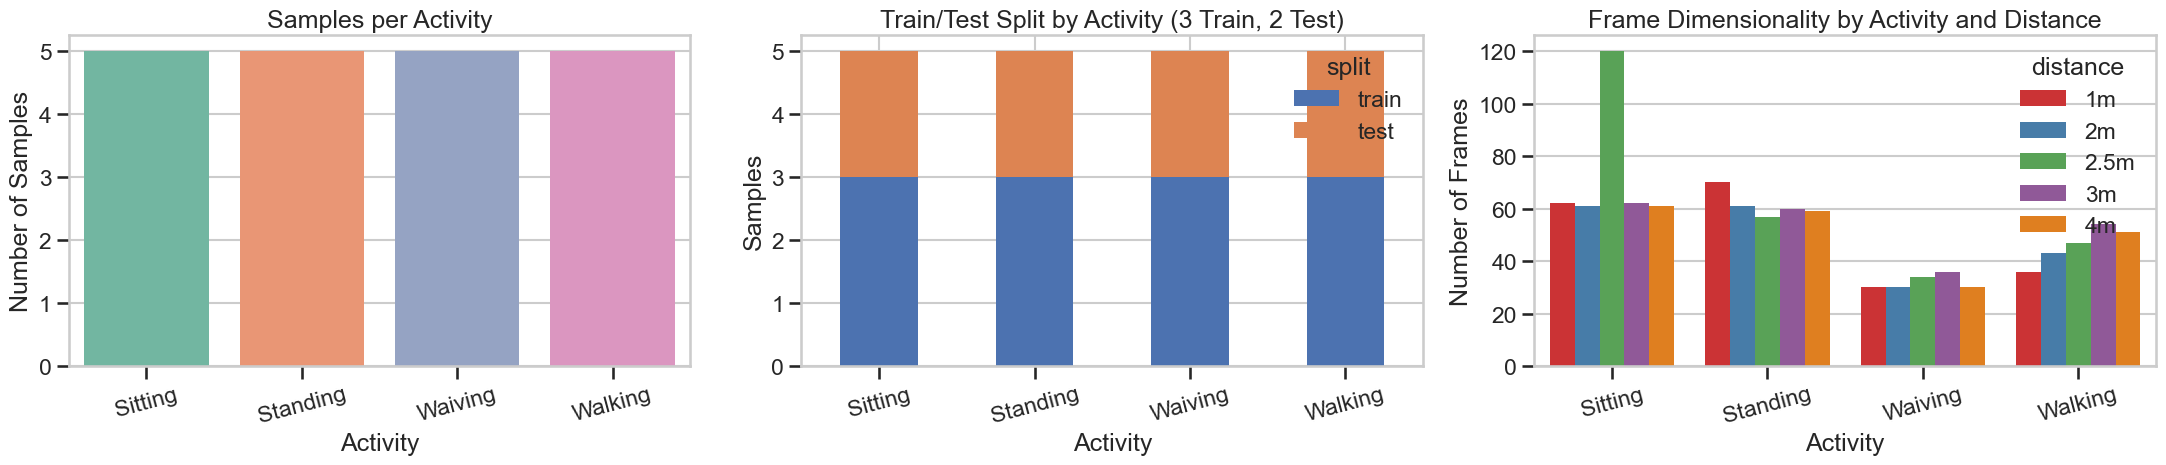

Dimensionality table (requested columns):


,Activity,Distance,Frames,RD_Points,Split,Target_Class_ID
0,Sitting,1m,62,507904,train,0
1,Sitting,2m,61,499712,train,0
2,Sitting,2.5m,120,983040,train,0
3,Sitting,3m,62,507904,test,0
4,Sitting,4m,61,499712,test,0
5,Standing,1m,70,573440,train,1
6,Standing,2m,61,499712,train,1
7,Standing,2.5m,57,466944,train,1
8,Standing,3m,60,491520,test,1
9,Standing,4m,59,483328,test,1



Numeric summary for activity recognition:


,count,mean,std,min,25%,50%,75%,max
Frames,20.0,53.2,20.389884,30.0,36.0,55.5,61.0,120.0
RD_Points,20.0,435814.4,167033.929505,245760.0,294912.0,454656.0,499712.0,983040.0


In [24]:
# Dimensionality and split visualization (before training)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# 1) Number of samples per activity
sample_counts = split_meta.groupby("activity").size().reindex(EXPECTED_ACTIVITIES)
sns.barplot(x=sample_counts.index, y=sample_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Samples per Activity")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=15)

# 2) Split distribution: train/test per activity
split_counts = split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0).reindex(EXPECTED_ACTIVITIES)
split_counts[["train", "test"]].plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Train/Test Split by Activity (3 Train, 2 Test)")
axes[1].set_xlabel("Activity")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=15)

# 3) Frames by activity and distance
tmp = split_meta.copy()
tmp["distance"] = pd.Categorical(tmp["distance"], categories=sorted(tmp["distance"].unique(), key=lambda x: float(str(x).replace('m','')) if str(x).replace('m','').replace('.','',1).isdigit() else 999), ordered=True)
sns.barplot(data=tmp, x="activity", y="n_frames", hue="distance", ax=axes[2], palette="Set1")
axes[2].set_title("Frame Dimensionality by Activity and Distance")
axes[2].set_xlabel("Activity")
axes[2].set_ylabel("Number of Frames")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("Dimensionality table (requested columns):")
display(split_meta_view)

print("\nNumeric summary for activity recognition:")
summary = split_meta_view[["Frames", "RD_Points"]].describe().T
display(summary)

In [25]:
# Build tensors from playback-style filtered spectrograms
SPATIAL_SIZE = (64, 64)   # CNN image size for spectrogram
SEQ_LEN = 64              # LSTM temporal length
WINDOW_LEN = 32           # Time window per training example
WINDOWS_PER_SAMPLE = 4
PLAYBACK_MIN = 2048.0
PLAYBACK_MAX = 4096.0

label_to_idx = {a: i for i, a in enumerate(EXPECTED_ACTIVITIES)}
idx_to_label = {i: a for a, i in label_to_idx.items()}


def robust_abs_z(values: np.ndarray) -> np.ndarray:
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    if mad < 1e-9:
        return np.zeros_like(values)
    return np.abs((values - med) / (1.4826 * mad))


def filter_anomalous_cube(cube: np.ndarray) -> np.ndarray:
    # Same idea used in playback: remove clearly corrupted frames only.
    if cube.shape[0] < 5:
        return cube

    means = cube.mean(axis=(1, 2))
    stds = cube.std(axis=(1, 2))
    peaks = cube.max(axis=(1, 2))
    sat_counts = (cube > 60000).sum(axis=(1, 2))

    z_mean = robust_abs_z(means)
    z_std = robust_abs_z(stds)
    z_peak = robust_abs_z(peaks)

    bad = (
        (sat_counts > 0)
        | (peaks > 10000)
        | (stds > 2000)
        | ((z_peak > 12.0) & (z_std > 12.0) & (z_mean > 12.0))
    )

    kept = cube[~bad]
    return kept if len(kept) > 0 else cube


def resize_2d(arr2d: np.ndarray, out_hw=(64, 64)) -> np.ndarray:
    zh = out_hw[0] / arr2d.shape[0]
    zw = out_hw[1] / arr2d.shape[1]
    return zoom(arr2d, (zh, zw), order=1)


def playback_like_process_frame(frame: np.ndarray, out_hw=(64, 64)) -> np.ndarray:
    # Playback-inspired processing for each range-doppler frame.
    shifted = np.fft.fftshift(frame, axes=1)
    rd = resize_2d(shifted, out_hw=out_hw)
    denom = max(PLAYBACK_MAX - PLAYBACK_MIN, 1e-9)
    norm = (rd - PLAYBACK_MIN) / denom
    return np.clip(norm, 0.0, 1.0).astype(np.float32)


def fix_sequence_len(seq: np.ndarray, seq_len: int) -> np.ndarray:
    n = seq.shape[0]
    if n == seq_len:
        return seq
    if n > seq_len:
        idx = np.linspace(0, n - 1, seq_len).astype(int)
        return seq[idx]
    pad_count = seq_len - n
    pad = np.repeat(seq[-1:, ...], pad_count, axis=0)
    return np.concatenate([seq, pad], axis=0)


def make_windows(seq: np.ndarray, win_len: int, n_windows: int) -> np.ndarray:
    # seq shape: [T, D] for spectrogram time slices
    t = seq.shape[0]
    if t <= win_len:
        one = fix_sequence_len(seq, win_len)
        return np.repeat(one[None, ...], n_windows, axis=0)

    starts = np.linspace(0, t - win_len, n_windows).astype(int)
    windows = [seq[s:s + win_len] for s in starts]
    return np.stack(windows, axis=0)


def normalize_spectrogram(spec: np.ndarray) -> np.ndarray:
    # spec: [T, D]
    # Remove static clutter per Doppler bin, then log compression.
    bg = np.median(spec, axis=0, keepdims=True)
    spec = np.clip(spec - bg, 0, None)
    spec = np.log1p(spec)
    lo, hi = np.percentile(spec, [1, 99])
    if hi - lo < 1e-9:
        return np.zeros_like(spec, dtype=np.float32)
    return np.clip((spec - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)


cnn_x, lstm_x, y = [], [], []
sample_trace = []

for _, row in split_meta.iterrows():
    df = read_longform(Path(row["csv_path"]))
    cube = dataframe_to_cube(df)  # [T, R, D]

    # 1) Remove anomalous frames (playback-style robustness)
    cube = filter_anomalous_cube(cube)

    # 2) Process each frame with playback-like normalization
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)  # [T, H, W]

    # 3) Build micro-Doppler-like spectrogram: sum over range -> [T, Doppler]
    # Here Doppler axis corresponds to W after FFT shift.
    spec_td = rd_frames.sum(axis=1)  # [T, W]
    spec_td = normalize_spectrogram(spec_td)

    # 4) Uniform temporal length, then windowing
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)                 # [64, 64]
    windows = make_windows(spec_td, WINDOW_LEN, WINDOWS_PER_SAMPLE)  # [Nw, 32, 64]

    for w in windows:
        # CNN uses a resized 2D spectrogram image.
        cnn_img = resize_2d(w, out_hw=SPATIAL_SIZE)[..., None]  # [64, 64, 1]

        # LSTM uses time-major sequence with Doppler features.
        lstm_seq = w  # [32, 64]

        cnn_x.append(cnn_img.astype(np.float32))
        lstm_x.append(lstm_seq.astype(np.float32))
        y.append(label_to_idx[row["activity"]])
        sample_trace.append(row["split"])

cnn_x = np.array(cnn_x, dtype=np.float32)
lstm_x = np.array(lstm_x, dtype=np.float32)
y = np.array(y, dtype=np.int32)
sample_trace = np.array(sample_trace)

is_train = (sample_trace == "train")
is_test = (sample_trace == "test")

x_train_cnn, x_test_cnn = cnn_x[is_train], cnn_x[is_test]
x_train_lstm, x_test_lstm = lstm_x[is_train], lstm_x[is_test]
y_train, y_test = y[is_train], y[is_test]

print("CNN train shape:", x_train_cnn.shape, "test:", x_test_cnn.shape)
print("LSTM train shape:", x_train_lstm.shape, "test:", x_test_lstm.shape)
print("y train/test:", y_train.shape, y_test.shape)

print("\nClass balance (train):")
print(pd.Series(y_train).map(idx_to_label).value_counts())
print("\nClass balance (test):")
print(pd.Series(y_test).map(idx_to_label).value_counts())

CNN train shape: (48, 64, 64, 1) test: (32, 64, 64, 1)
LSTM train shape: (48, 32, 64) test: (32, 32, 64)
y train/test: (48,) (32,)

Class balance (train):
Sitting     12
Standing    12
Waiving     12
Walking     12
Name: count, dtype: int64

Class balance (test):
Sitting     8
Standing    8
Waiving     8
Walking     8
Name: count, dtype: int64


In [26]:
from sklearn.utils.class_weight import compute_class_weight


def build_cnn_baseline(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_cnn_enhanced(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_lstm_baseline(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_lstm_enhanced(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.35),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])


def train_model(model, x_train, y_train, x_val, y_val, epochs=80, batch_size=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ]

    classes = np.unique(y_train)
    cls_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(classes, cls_weights)}

    hist = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks,
        class_weight=class_weight,
    )
    return hist


n_classes = len(EXPECTED_ACTIVITIES)

ablation_models = {
    "CNN_Baseline": build_cnn_baseline(x_train_cnn.shape[1:], n_classes),
    "CNN_Enhanced": build_cnn_enhanced(x_train_cnn.shape[1:], n_classes),
    "LSTM_Baseline": build_lstm_baseline(x_train_lstm.shape[1:], n_classes),
    "LSTM_Enhanced": build_lstm_enhanced(x_train_lstm.shape[1:], n_classes),
}

ablation_histories = {}
for name, model in ablation_models.items():
    print(f"\n=== Training {name} ===")
    if "CNN" in name:
        hist = train_model(model, x_train_cnn, y_train, x_test_cnn, y_test, epochs=80, batch_size=8)
    else:
        hist = train_model(model, x_train_lstm, y_train, x_test_lstm, y_test, epochs=80, batch_size=8)
    ablation_histories[name] = hist

# Keep compatibility with previous cell names
cnn_model = ablation_models["CNN_Enhanced"]
lstm_model = ablation_models["LSTM_Enhanced"]
cnn_history = ablation_histories["CNN_Enhanced"]
lstm_history = ablation_histories["LSTM_Enhanced"]


=== Training CNN_Baseline ===
Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.2914 - loss: 1.3777 - val_accuracy: 0.2500 - val_loss: 1.3726 - learning_rate: 0.0010
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2914 - loss: 1.3680 - val_accuracy: 0.2500 - val_loss: 1.3631 - learning_rate: 0.0010
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2914 - loss: 1.3506 - val_accuracy: 0.2500 - val_loss: 1.3535 - learning_rate: 0.0010
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2914 - loss: 1.3330 - val_accuracy: 0.2500 - val_loss: 1.3413 - learning_rate: 0.0010
Epoch 5/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2914 - loss: 1.3094 - val_accuracy: 0.2500 - val_loss: 1.3192 - learning_rate: 0.0010
Epoch 6/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2914 - loss: 1.2983 - val_accuracy: 0.2500 - val_loss: 1.2857 - learning_rate: 0.0010
Epoch 7/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4964 - loss:

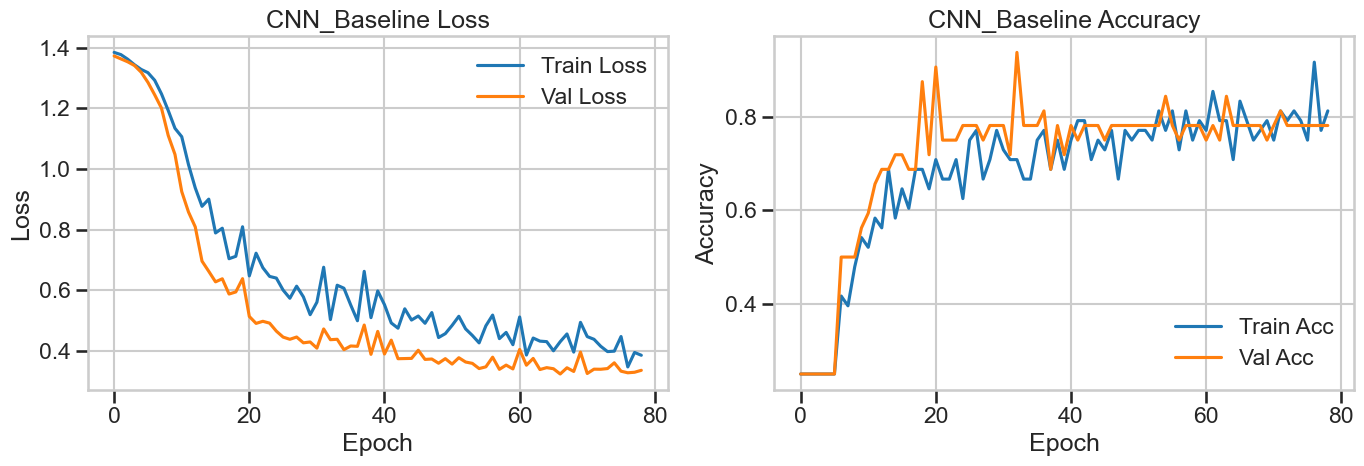

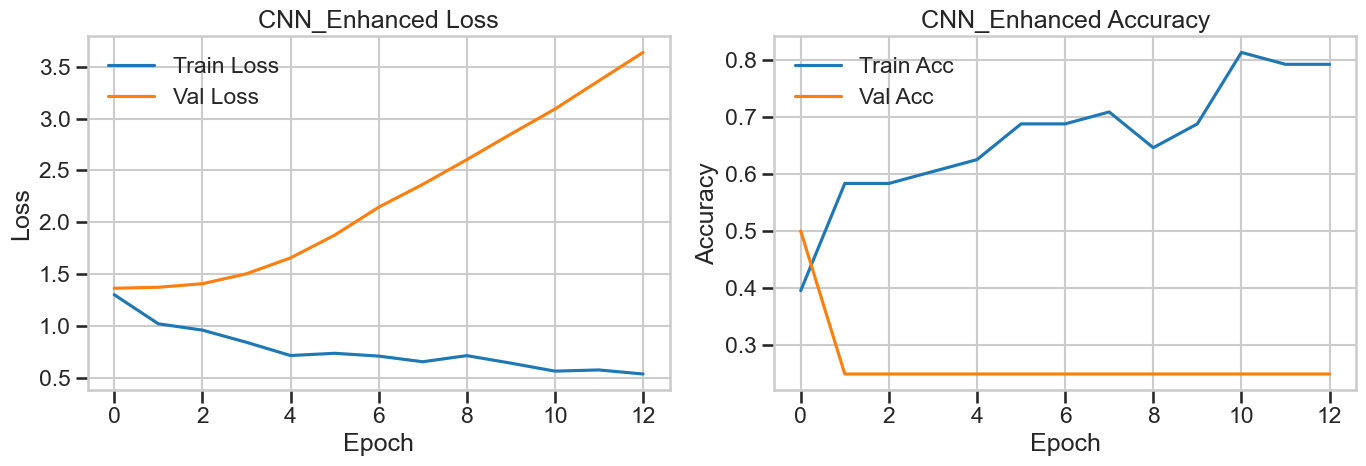

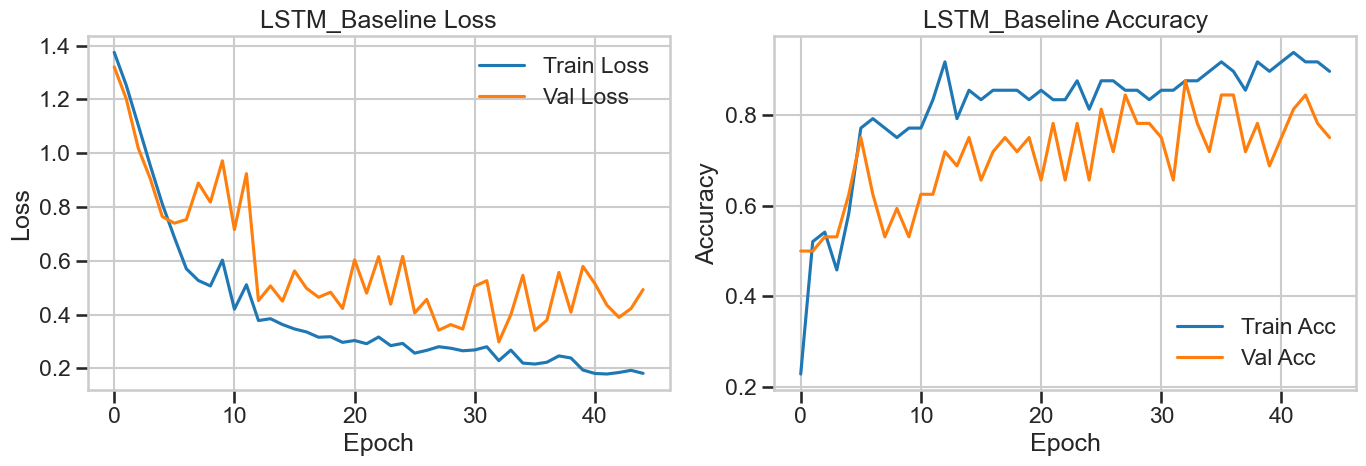

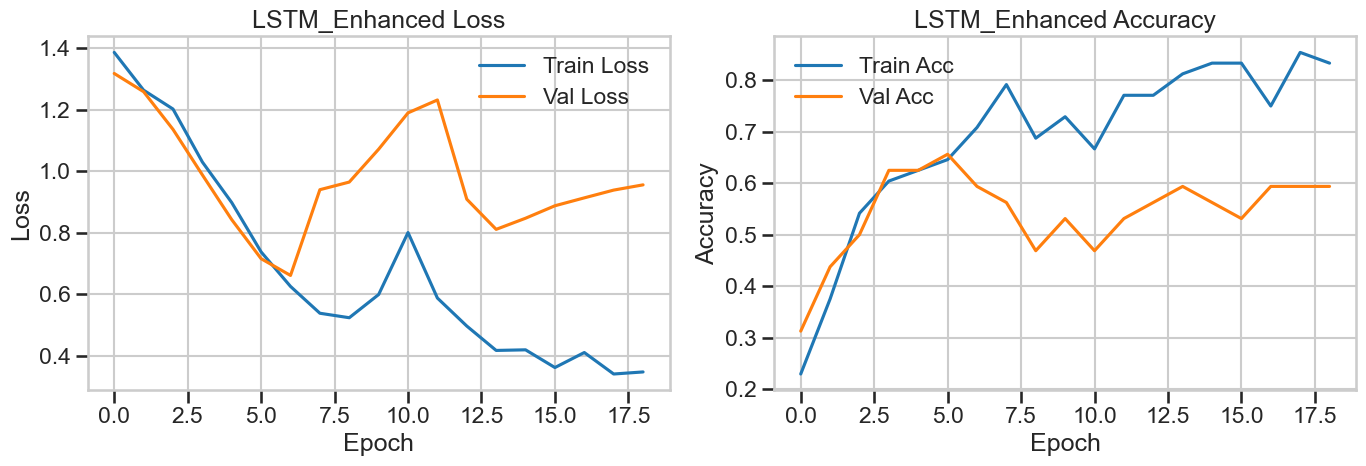

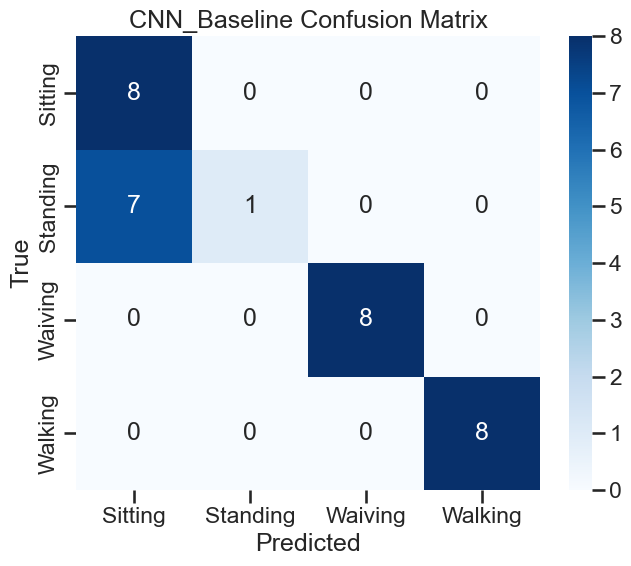


CNN_Baseline Classification Report
              precision    recall  f1-score   support

     Sitting     0.5333    1.0000    0.6957         8
    Standing     1.0000    0.1250    0.2222         8
     Waiving     1.0000    1.0000    1.0000         8
     Walking     1.0000    1.0000    1.0000         8

    accuracy                         0.7812        32
   macro avg     0.8833    0.7812    0.7295        32
weighted avg     0.8833    0.7812    0.7295        32



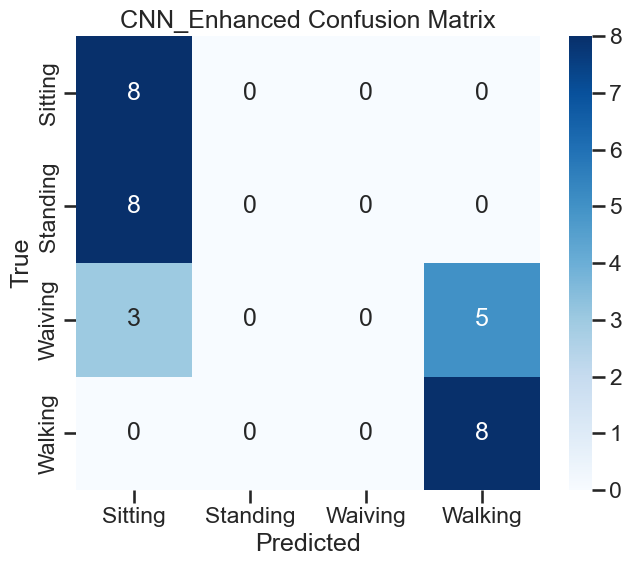


CNN_Enhanced Classification Report
              precision    recall  f1-score   support

     Sitting     0.4211    1.0000    0.5926         8
    Standing     0.0000    0.0000    0.0000         8
     Waiving     0.0000    0.0000    0.0000         8
     Walking     0.6154    1.0000    0.7619         8

    accuracy                         0.5000        32
   macro avg     0.2591    0.5000    0.3386        32
weighted avg     0.2591    0.5000    0.3386        32



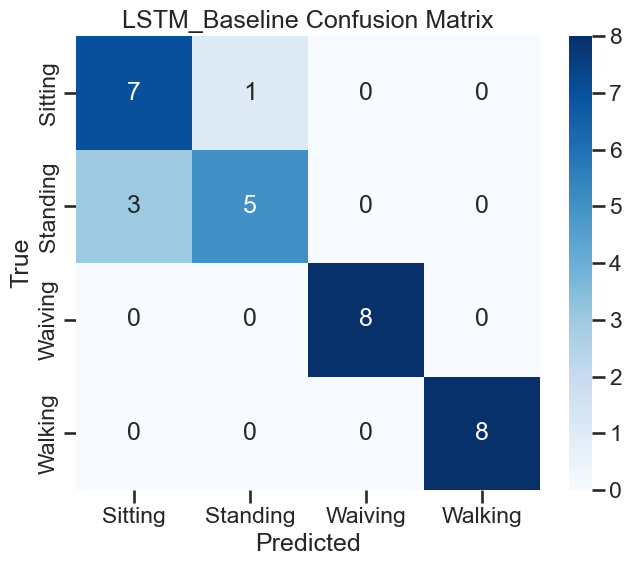


LSTM_Baseline Classification Report
              precision    recall  f1-score   support

     Sitting     0.7000    0.8750    0.7778         8
    Standing     0.8333    0.6250    0.7143         8
     Waiving     1.0000    1.0000    1.0000         8
     Walking     1.0000    1.0000    1.0000         8

    accuracy                         0.8750        32
   macro avg     0.8833    0.8750    0.8730        32
weighted avg     0.8833    0.8750    0.8730        32



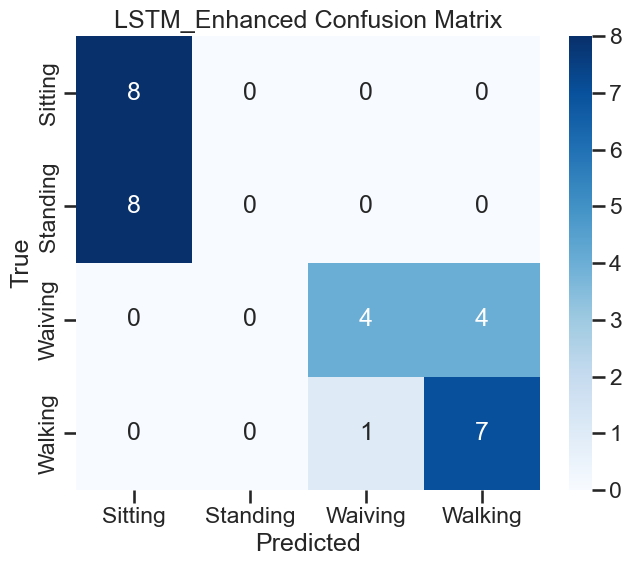


LSTM_Enhanced Classification Report
              precision    recall  f1-score   support

     Sitting     0.5000    1.0000    0.6667         8
    Standing     0.0000    0.0000    0.0000         8
     Waiving     0.8000    0.5000    0.6154         8
     Walking     0.6364    0.8750    0.7368         8

    accuracy                         0.5938        32
   macro avg     0.4841    0.5938    0.5047        32
weighted avg     0.4841    0.5938    0.5047        32


Ablation Report (sorted by Test Accuracy):


,Model,Test Accuracy,Macro F1,Weighted F1
0,LSTM_Baseline,0.8750,0.8730,0.8730
1,CNN_Baseline,0.7812,0.7295,0.7295
2,LSTM_Enhanced,0.5938,0.5047,0.5047
3,CNN_Enhanced,0.5000,0.3386,0.3386


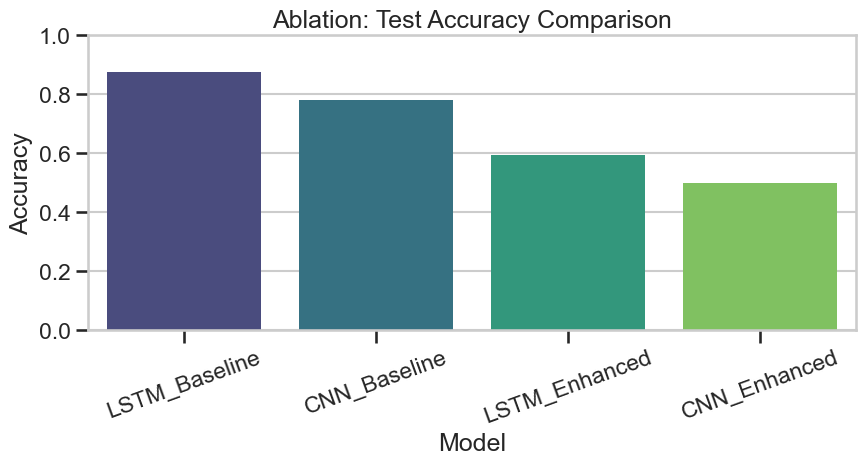

Best model: LSTM_Baseline | Accuracy=0.8750, Macro-F1=0.8730, Weighted-F1=0.8730


In [27]:
from sklearn.metrics import f1_score, accuracy_score


def plot_history(history, title_prefix="Model"):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h["loss"], label="Train Loss")
    axes[0].plot(h["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(h["accuracy"], label="Train Acc")
    axes[1].plot(h["val_accuracy"], label="Val Acc")
    axes[1].set_title(f"{title_prefix} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, x_test, y_test, labels, title="Model", show_cm=True):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    if show_cm:
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)))
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)

        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{title} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

        print(f"\n{title} Classification Report")
        print(classification_report(y_test, y_pred, target_names=labels, digits=4))

    return {
        "Model": title,
        "Test Accuracy": acc,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
    }


labels = EXPECTED_ACTIVITIES

# Plot training curves for all ablation models
for name, hist in ablation_histories.items():
    plot_history(hist, name)

# Build ablation report
ablation_rows = []
for name, model in ablation_models.items():
    if "CNN" in name:
        row = evaluate_classifier(model, x_test_cnn, y_test, labels, title=name, show_cm=True)
    else:
        row = evaluate_classifier(model, x_test_lstm, y_test, labels, title=name, show_cm=True)
    ablation_rows.append(row)

ablation_report = pd.DataFrame(ablation_rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print("\nAblation Report (sorted by Test Accuracy):")
display(ablation_report.style.format({
    "Test Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
}))

plt.figure(figsize=(9, 5))
sns.barplot(data=ablation_report, x="Model", y="Test Accuracy", palette="viridis")
plt.ylim(0, 1)
plt.title("Ablation: Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_row = ablation_report.iloc[0]
print(
    f"Best model: {best_row['Model']} | "
    f"Accuracy={best_row['Test Accuracy']:.4f}, "
    f"Macro-F1={best_row['Macro F1']:.4f}, "
    f"Weighted-F1={best_row['Weighted F1']:.4f}"
)

## Cell 9: Social Behaviour Classification (Research Data Folder)

This section applies the same refined pipeline to:

`Research Data/Social Behaviour/2 People`

Target interaction classes:
- Approaching
- Sitting
- Splitting
- Standing
- Walking_togather

Workflow for social behaviour:
1. Recursively scan for `range_doppler.csv` under each social class folder.
2. Create a sample-level train/test split per class (60/40 where possible).
3. Build robust temporal features: velocity, acceleration, spectral entropy, spectral energy.
4. Train an LSTM classifier and evaluate with confusion matrix + report.


In [37]:
# Social behaviour data scan + split
SOCIAL_ROOT = Path.cwd() / "Research Data" / "Social Behaviour" / "2 People"
SOCIAL_EXPECTED = ["Approaching", "Sitting", "Splitting", "Standing", "Walking_togather"]

if not SOCIAL_ROOT.exists():
    raise FileNotFoundError(f"Social Behaviour folder not found: {SOCIAL_ROOT}")


def discover_rd_csvs(root: Path) -> list[Path]:
    # Recursive discovery handles unknown folder depth.
    return sorted(root.rglob("range_doppler.csv"))


def build_social_meta(root: Path, expected_classes: list[str]) -> pd.DataFrame:
    rows = []
    for cls in expected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing class folder: {cls_dir}")
            continue

        csv_files = discover_rd_csvs(cls_dir)
        if len(csv_files) == 0:
            print(f"Warning: no range_doppler.csv found for class: {cls}")
            continue

        for csv_path in csv_files:
            df = read_longform(csv_path)
            rel = csv_path.relative_to(cls_dir)
            sample_name = str(rel.parent) if str(rel.parent) != "." else csv_path.stem
            rows.append(
                {
                    "social_class": cls,
                    "sample_name": sample_name,
                    "csv_path": csv_path,
                    "rd_points": len(df),
                    "n_frames": int(df["frame_number"].nunique()),
                }
            )

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError("No social behaviour samples found under Social Behaviour/2 People")

    return meta.sort_values(["social_class", "sample_name"]).reset_index(drop=True)


def split_social_by_sample(meta: pd.DataFrame, train_ratio: float = 0.6) -> pd.DataFrame:
    out = meta.copy()
    out["split"] = ""

    for cls, g in out.groupby("social_class"):
        g = g.sort_values("sample_name")
        n = len(g)
        n_train = max(1, int(round(n * train_ratio)))
        if n > 1:
            n_train = min(n_train, n - 1)

        train_idx = g.index[:n_train]
        test_idx = g.index[n_train:]
        out.loc[train_idx, "split"] = "train"
        out.loc[test_idx, "split"] = "test"

        if len(test_idx) == 0:
            # Defensive fallback if class has only one sample.
            out.loc[train_idx[-1], "split"] = "test"

    return out


social_meta = build_social_meta(SOCIAL_ROOT, SOCIAL_EXPECTED)
social_split_meta = split_social_by_sample(social_meta, train_ratio=0.6)

social_label_to_idx = {c: i for i, c in enumerate(sorted(social_split_meta["social_class"].unique()))}
social_idx_to_label = {i: c for c, i in social_label_to_idx.items()}

social_view = social_split_meta.copy()
social_view["Target_Class_ID"] = social_view["social_class"].map(social_label_to_idx)
social_view = social_view.rename(
    columns={
        "social_class": "Social_Class",
        "sample_name": "Sample",
        "n_frames": "Frames",
        "rd_points": "RD_Points",
        "split": "Split",
    }
)

social_view = social_view[["Social_Class", "Sample", "Frames", "RD_Points", "Split", "Target_Class_ID"]]

print("Using social behaviour root:", SOCIAL_ROOT)
print("\nSocial behaviour sample table:")
display(social_view)

print("\nSamples per social class and split:")
print(social_split_meta.groupby(["social_class", "split"]).size().unstack(fill_value=0))


Using social behaviour root: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Research Data\Social Behaviour\2 People

Social behaviour sample table:


,Social_Class,Sample,Frames,RD_Points,Split,Target_Class_ID
0,Approaching,1m,36,147456,train,0
1,Approaching,2m,63,516096,train,0
2,Approaching,3m,0,0,train,0
3,Approaching,radar_data_20251209_173331,35,286720,train,0
4,Approaching,radar_data_20251209_173758,25,102400,test,0
5,Approaching,radar_data_20251209_174007,0,0,test,0
6,Sitting,1m,17,139264,train,1
7,Sitting,2m,32,131072,train,1
8,Sitting,3m,19,155648,train,1
9,Sitting,radar_data_20251209_181620,26,212992,test,1



Samples per social class and split:
split             test  train
social_class                 
Approaching          2      4
Sitting              2      3
Splitting            2      3
Standing             2      3
Walking_togather     2      3


Social feature tensors:
x_train_social: (60, 32, 4) x_test_social: (36, 32, 4)
y_train_social: (60,) y_test_social: (36,)

Skipped malformed files: 2

Train class balance:
Approaching         12
Sitting             12
Splitting           12
Standing            12
Walking_togather    12
Name: count, dtype: int64

Test class balance:
Sitting             8
Splitting           8
Standing            8
Walking_togather    8
Approaching         4
Name: count, dtype: int64

Training social behaviour LSTM...
Epoch 1/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.1378 - loss: 1.6665 - val_accuracy: 0.2222 - val_loss: 1.6553 - learning_rate: 0.0010
Epoch 2/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2814 - loss: 1.6028 - val_accuracy: 0.1944 - val_loss: 1.6487 - learning_rate: 0.0010
Epoch 3/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2273 - loss: 1.6343 - val_accuracy: 0.2222 - val_loss: 1.6332 - learning_rate: 0.0010
Epoch 4/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/

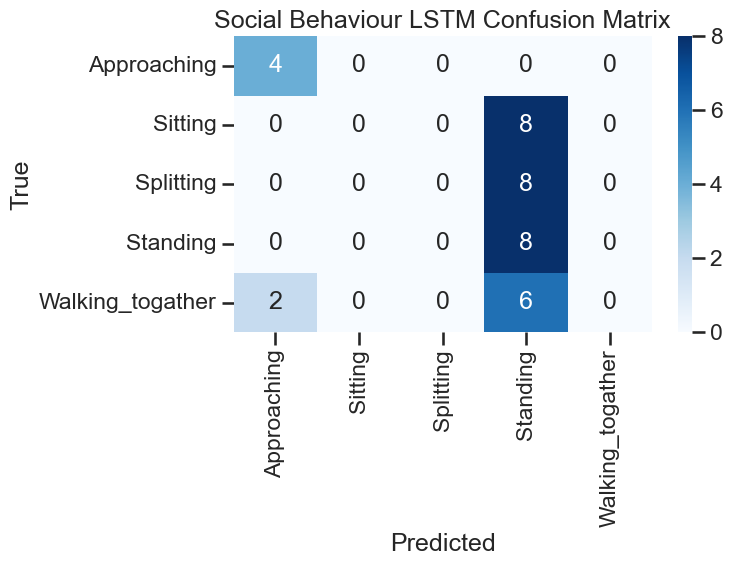


Classification report:
                  precision    recall  f1-score   support

     Approaching     0.6667    1.0000    0.8000         4
         Sitting     0.0000    0.0000    0.0000         8
       Splitting     0.0000    0.0000    0.0000         8
        Standing     0.2667    1.0000    0.4211         8
Walking_togather     0.0000    0.0000    0.0000         8

        accuracy                         0.3333        36
       macro avg     0.1867    0.4000    0.2442        36
    weighted avg     0.1333    0.3333    0.1825        36



In [39]:
# Build refined feature vectors for social behaviour + train/evaluate LSTM

from sklearn.utils.class_weight import compute_class_weight


def extract_social_features(spec_td: np.ndarray) -> np.ndarray:
    # Velocity centroid across Doppler bins.
    doppler_bins = np.arange(spec_td.shape[1], dtype=np.float32)
    intensity = np.sum(spec_td, axis=1, keepdims=True) + 1e-9
    velocity = np.sum(spec_td * doppler_bins[None, :], axis=1) / intensity[:, 0]

    # Temporal change magnitude.
    dt = np.diff(spec_td, axis=0, prepend=spec_td[0:1])
    accel = np.sqrt(np.sum(dt ** 2, axis=1))

    # Spectral complexity and energy.
    entropy = -np.sum((spec_td + 1e-9) * np.log(spec_td + 1e-9), axis=1)
    energy = np.sum(spec_td, axis=1)

    return np.stack([velocity, accel, entropy, energy], axis=1).astype(np.float32)


social_x, social_y, social_trace = [], [], []
skipped_social_files = []

for _, row in social_split_meta.iterrows():
    df = read_longform(Path(row["csv_path"]))

    # Skip malformed/empty files safely.
    if df.empty:
        skipped_social_files.append(str(row["csv_path"]))
        continue

    if df[["frame_number", "range_bin", "doppler_bin"]].isna().any().any():
        skipped_social_files.append(str(row["csv_path"]))
        continue

    if df["frame_number"].nunique() == 0:
        skipped_social_files.append(str(row["csv_path"]))
        continue

    try:
        cube = dataframe_to_cube(df)
    except Exception:
        skipped_social_files.append(str(row["csv_path"]))
        continue

    if cube.size == 0 or cube.shape[0] == 0:
        skipped_social_files.append(str(row["csv_path"]))
        continue

    cube = filter_anomalous_cube(cube)
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)

    spec_td = rd_frames.sum(axis=1)
    spec_td = normalize_spectrogram(spec_td)
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)

    feat = extract_social_features(spec_td)                        # [64, 4]
    windows = make_windows(feat, WINDOW_LEN, WINDOWS_PER_SAMPLE)   # [Nw, 32, 4]

    for w in windows:
        social_x.append(w.astype(np.float32))
        social_y.append(social_label_to_idx[row["social_class"]])
        social_trace.append(row["split"])

if len(social_x) == 0:
    raise RuntimeError("No valid social behaviour windows after filtering malformed files.")

social_x = np.array(social_x, dtype=np.float32)
social_y = np.array(social_y, dtype=np.int32)
social_trace = np.array(social_trace)

social_train_mask = social_trace == "train"
social_test_mask = social_trace == "test"

x_train_social = social_x[social_train_mask]
x_test_social = social_x[social_test_mask]
y_train_social = social_y[social_train_mask]
y_test_social = social_y[social_test_mask]

if x_train_social.shape[0] == 0 or x_test_social.shape[0] == 0:
    raise RuntimeError("Social train/test split is empty after filtering. Check CSV quality or split ratio.")

print("Social feature tensors:")
print("x_train_social:", x_train_social.shape, "x_test_social:", x_test_social.shape)
print("y_train_social:", y_train_social.shape, "y_test_social:", y_test_social.shape)
if skipped_social_files:
    print(f"\nSkipped malformed files: {len(skipped_social_files)}")

print("\nTrain class balance:")
print(pd.Series(y_train_social).map(social_idx_to_label).value_counts())

print("\nTest class balance:")
print(pd.Series(y_test_social).map(social_idx_to_label).value_counts())


def build_social_lstm(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(96, return_sequences=True, dropout=0.3),
        layers.LSTM(64, return_sequences=False, dropout=0.25),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])


def train_social_model(model, x_train, y_train, x_val, y_val, epochs=120, batch_size=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    classes = np.unique(y_train)
    cls_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(classes, cls_weights)}

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        class_weight=class_weight,
        callbacks=callbacks,
    )
    return history


social_labels = [social_idx_to_label[i] for i in range(len(social_idx_to_label))]
social_model = build_social_lstm(x_train_social.shape[1:], n_classes=len(social_labels))

print("\nTraining social behaviour LSTM...")
social_history = train_social_model(
    social_model,
    x_train_social,
    y_train_social,
    x_test_social,
    y_test_social,
    epochs=120,
    batch_size=8,
)

# Evaluate
social_prob = social_model.predict(x_test_social, verbose=0)
social_pred = np.argmax(social_prob, axis=1)

social_acc = accuracy_score(y_test_social, social_pred)
social_f1_macro = f1_score(y_test_social, social_pred, average="macro")
social_f1_weighted = f1_score(y_test_social, social_pred, average="weighted")

print("\nSocial Behaviour Results:")
print(f"Accuracy:    {social_acc:.4f}")
print(f"Macro-F1:    {social_f1_macro:.4f}")
print(f"Weighted-F1: {social_f1_weighted:.4f}")

cm = confusion_matrix(y_test_social, social_pred, labels=np.arange(len(social_labels)))
cm_df = pd.DataFrame(cm, index=social_labels, columns=social_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Social Behaviour LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test_social, social_pred, target_names=social_labels, digits=4))

Classical ML feature shapes: (60, 18) (36, 18)
Skipped malformed files for ML: 2

Social Behaviour Classical ML Comparison:


,Model,Accuracy,Macro-F1,Weighted-F1
0,SVM_RBF,0.3889,0.3729,0.4004
1,RandomForest,0.1944,0.1778,0.1975



Best model: SVM_RBF


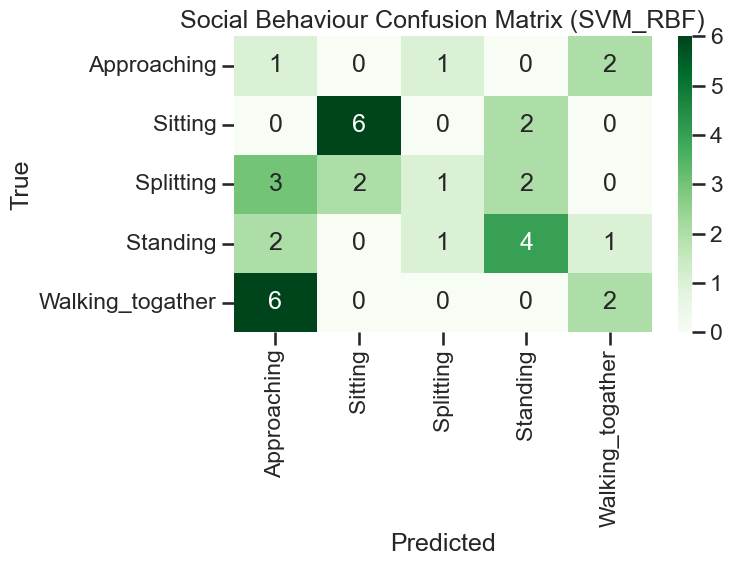


Classification report (best model):
                  precision    recall  f1-score   support

     Approaching     0.0833    0.2500    0.1250         4
         Sitting     0.7500    0.7500    0.7500         8
       Splitting     0.3333    0.1250    0.1818         8
        Standing     0.5000    0.5000    0.5000         8
Walking_togather     0.4000    0.2500    0.3077         8

        accuracy                         0.3889        36
       macro avg     0.4133    0.3750    0.3729        36
    weighted avg     0.4500    0.3889    0.4004        36



In [40]:
# Social behaviour improvement cell: classical ML on robust handcrafted features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


def social_window_features(spec_win: np.ndarray) -> np.ndarray:
    """Compact handcrafted features for small-data classification.
    spec_win: [T, D]
    """
    doppler_bins = np.arange(spec_win.shape[1], dtype=np.float32)
    energy_t = np.sum(spec_win, axis=1) + 1e-9
    vel_t = np.sum(spec_win * doppler_bins[None, :], axis=1) / energy_t

    dt = np.diff(spec_win, axis=0, prepend=spec_win[0:1])
    accel_t = np.sqrt(np.sum(dt ** 2, axis=1))
    entropy_t = -np.sum((spec_win + 1e-9) * np.log(spec_win + 1e-9), axis=1)

    thirds = np.array_split(np.arange(spec_win.shape[1]), 3)
    band_energy = [np.mean(spec_win[:, b]) for b in thirds]

    feat = np.array([
        np.mean(vel_t), np.std(vel_t), np.ptp(vel_t),
        np.mean(energy_t), np.std(energy_t), np.ptp(energy_t),
        np.mean(accel_t), np.std(accel_t), np.max(accel_t),
        np.mean(entropy_t), np.std(entropy_t), np.ptp(entropy_t),
        band_energy[0], band_energy[1], band_energy[2],
        np.mean(spec_win), np.std(spec_win), np.max(spec_win),
    ], dtype=np.float32)
    return feat


X_social, y_social, split_social = [], [], []
skipped_for_ml = 0

for _, row in social_split_meta.iterrows():
    df = read_longform(Path(row["csv_path"]))
    if df.empty:
        skipped_for_ml += 1
        continue

    try:
        cube = dataframe_to_cube(df)
    except Exception:
        skipped_for_ml += 1
        continue

    if cube.size == 0 or cube.shape[0] == 0:
        skipped_for_ml += 1
        continue

    cube = filter_anomalous_cube(cube)
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)

    spec_td = rd_frames.sum(axis=1)
    spec_td = normalize_spectrogram(spec_td)
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)

    wins = make_windows(spec_td, WINDOW_LEN, WINDOWS_PER_SAMPLE)
    for w in wins:
        X_social.append(social_window_features(w))
        y_social.append(social_label_to_idx[row["social_class"]])
        split_social.append(row["split"])

X_social = np.array(X_social, dtype=np.float32)
y_social = np.array(y_social, dtype=np.int32)
split_social = np.array(split_social)

train_m = split_social == "train"
test_m = split_social == "test"

X_train_social, X_test_social = X_social[train_m], X_social[test_m]
y_train_social_ml, y_test_social_ml = y_social[train_m], y_social[test_m]

print("Classical ML feature shapes:", X_train_social.shape, X_test_social.shape)
print("Skipped malformed files for ML:", skipped_for_ml)

social_labels = [social_idx_to_label[i] for i in range(len(social_idx_to_label))]

# Two models, pick best by macro-F1
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced", probability=True, random_state=SEED)),
])

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=SEED,
)

candidates = {
    "SVM_RBF": svm_clf,
    "RandomForest": rf_clf,
}

rows = []
best_name, best_model, best_pred, best_macro = None, None, None, -1.0

for name, clf in candidates.items():
    clf.fit(X_train_social, y_train_social_ml)
    pred = clf.predict(X_test_social)

    acc = accuracy_score(y_test_social_ml, pred)
    macro = f1_score(y_test_social_ml, pred, average="macro")
    weighted = f1_score(y_test_social_ml, pred, average="weighted")

    rows.append({"Model": name, "Accuracy": acc, "Macro-F1": macro, "Weighted-F1": weighted})

    if macro > best_macro:
        best_macro = macro
        best_name = name
        best_model = clf
        best_pred = pred

social_ml_report = pd.DataFrame(rows).sort_values("Macro-F1", ascending=False).reset_index(drop=True)
print("\nSocial Behaviour Classical ML Comparison:")
display(social_ml_report.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))

print(f"\nBest model: {best_name}")
cm = confusion_matrix(y_test_social_ml, best_pred, labels=np.arange(len(social_labels)))
cm_df = pd.DataFrame(cm, index=social_labels, columns=social_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title(f"Social Behaviour Confusion Matrix ({best_name})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nClassification report (best model):")
print(classification_report(y_test_social_ml, best_pred, target_names=social_labels, digits=4))

## Cell 13: Single Activity (Research Data) - Full Session Pipeline

This section rebuilds the experiment on:

`Research Data/Single Activity Data`

using session-level sample split (60% train / 40% test per activity), robust preprocessing, and a **12-feature vector** per time step built from:

- `range_doppler.csv` (primary motion signature)
- `points_cloud.csv` (optional density cue)
- `noise_snr.csv` (optional quality/noise cue)

Models trained:
- **LSTM** on feature sequence `[T, 12]`
- **CNN** on imageized feature map `[64, 64, 1]`


In [48]:
# Single Activity data discovery + dimensionality table (60/40 split per activity)
SA_ROOT = Path.cwd() / "Research Data" / "Single Activity Data"
SA_ACTIVITIES = ["Sitting", "Standing", "Waiving", "Walking"]

if not SA_ROOT.exists():
    raise FileNotFoundError(f"Single Activity folder not found: {SA_ROOT}")


def safe_numeric_values(csv_path: Path) -> np.ndarray:
    """Read any CSV and return finite numeric values as 1D vector."""
    if not csv_path.exists():
        return np.array([], dtype=np.float32)
    try:
        raw = pd.read_csv(csv_path, header=None)
    except Exception:
        return np.array([], dtype=np.float32)
    vals = pd.to_numeric(raw.stack(), errors="coerce").to_numpy(dtype=np.float32)
    vals = vals[np.isfinite(vals)]
    return vals


def build_sa_meta(root: Path, activities: list[str]) -> pd.DataFrame:
    rows = []
    for act in activities:
        act_dir = root / act
        if not act_dir.exists():
            print(f"Warning: missing activity folder: {act_dir}")
            continue

        # Use every session folder that has range_doppler.csv
        session_dirs = sorted([d for d in act_dir.rglob("*") if d.is_dir() and (d / "range_doppler.csv").exists()])
        for sdir in session_dirs:
            rd_csv = sdir / "range_doppler.csv"
            pc_csv = sdir / "points_cloud.csv"
            ns_csv = sdir / "noise_snr.csv"

            df = read_longform(rd_csv)
            rows.append(
                {
                    "activity": act,
                    "session": str(sdir.relative_to(act_dir)).replace("\\", "/"),
                    "session_dir": sdir,
                    "range_doppler_csv": rd_csv,
                    "points_cloud_csv": pc_csv,
                    "noise_snr_csv": ns_csv,
                    "has_points_cloud": pc_csv.exists(),
                    "has_noise_snr": ns_csv.exists(),
                    "n_frames": int(df["frame_number"].nunique()) if not df.empty else 0,
                    "rd_points": int(len(df)),
                }
            )

    meta = pd.DataFrame(rows)
    if meta.empty:
        raise RuntimeError("No single-activity sessions found with range_doppler.csv")

    return meta.sort_values(["activity", "session"]).reset_index(drop=True)


def split_sa_samples(meta: pd.DataFrame, train_ratio: float = 0.6) -> pd.DataFrame:
    out = meta.copy()
    out["split"] = ""

    for act, g in out.groupby("activity"):
        g = g.sort_values("session")
        n = len(g)
        n_train = max(1, int(round(n * train_ratio)))
        if n > 1:
            n_train = min(n_train, n - 1)

        train_idx = g.index[:n_train]
        test_idx = g.index[n_train:]
        out.loc[train_idx, "split"] = "train"
        out.loc[test_idx, "split"] = "test"

        if len(test_idx) == 0:
            out.loc[train_idx[-1], "split"] = "test"

    return out


sa_meta = build_sa_meta(SA_ROOT, SA_ACTIVITIES)
sa_split_meta = split_sa_samples(sa_meta, train_ratio=0.6)

sa_label_to_idx = {a: i for i, a in enumerate(SA_ACTIVITIES)}
sa_idx_to_label = {i: a for a, i in sa_label_to_idx.items()}

sa_view = sa_split_meta.copy()
sa_view["Target_Class_ID"] = sa_view["activity"].map(sa_label_to_idx)
sa_view = sa_view.rename(
    columns={
        "activity": "Activity",
        "session": "Session",
        "n_frames": "Frames",
        "rd_points": "RD_Points",
        "has_points_cloud": "Has_Points_Cloud",
        "has_noise_snr": "Has_Noise_SNR",
        "split": "Split",
    }
)
sa_view = sa_view[["Activity", "Session", "Frames", "RD_Points", "Has_Points_Cloud", "Has_Noise_SNR", "Split", "Target_Class_ID"]]

print("Using single activity root:", SA_ROOT)
print("\nDimensionality table (before training/testing):")
display(sa_view)

print("\nSplit count per activity:")
print(sa_split_meta.groupby(["activity", "split"]).size().unstack(fill_value=0))

print("\nDimensionality summary:")
display(sa_view[["Frames", "RD_Points"]].describe().T)


Using single activity root: c:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Research Data\Single Activity Data

Dimensionality table (before training/testing):


,Activity,Session,Frames,RD_Points,Has_Points_Cloud,Has_Noise_SNR,Split,Target_Class_ID
0,Sitting,1m,62,507904,True,True,train,0
1,Sitting,2.5,120,983040,True,True,train,0
2,Sitting,2m,61,499712,True,True,train,0
3,Sitting,3m,62,507904,True,True,test,0
4,Sitting,4.m,61,499712,True,True,test,0
5,Standing,1m,70,573440,True,True,train,1
6,Standing,2.5,57,466944,True,True,train,1
7,Standing,2m,61,499712,True,True,train,1
8,Standing,3m,60,491520,True,True,test,1
9,Standing,4.m,59,483328,True,True,test,1



Split count per activity:
split     test  train
activity             
Sitting      2      3
Standing     2      3
Waiving      2      3
Walking      2      3

Dimensionality summary:


,count,mean,std,min,25%,50%,75%,max
Frames,20.0,53.2,20.389884,30.0,36.0,55.5,61.0,120.0
RD_Points,20.0,435814.4,167033.929505,245760.0,294912.0,454656.0,499712.0,983040.0


Built single-activity tensors:
LSTM train/test: (48, 32, 12) (32, 32, 12)
CNN  train/test: (48, 64, 64, 1) (32, 64, 64, 1)
y train/test: (48,) (32,)

Training LSTM on 12-feature sequences...
Epoch 1/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.2964 - loss: 1.3833 - val_accuracy: 0.3438 - val_loss: 1.3800 - learning_rate: 0.0010
Epoch 2/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2268 - loss: 1.3526 - val_accuracy: 0.3438 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 3/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5568 - loss: 1.2682 - val_accuracy: 0.3438 - val_loss: 1.3546 - learning_rate: 0.0010
Epoch 4/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3214 - loss: 1.2937 - val_accuracy: 0.3750 - val_loss: 1.3396 - learning_rate: 0.0010
Epoch 5/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5720 - loss: 1.2013 - val_accuracy: 0.3750 - val_loss: 1.3219 - learning_rate: 0.0010
Epoch 6/90
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.

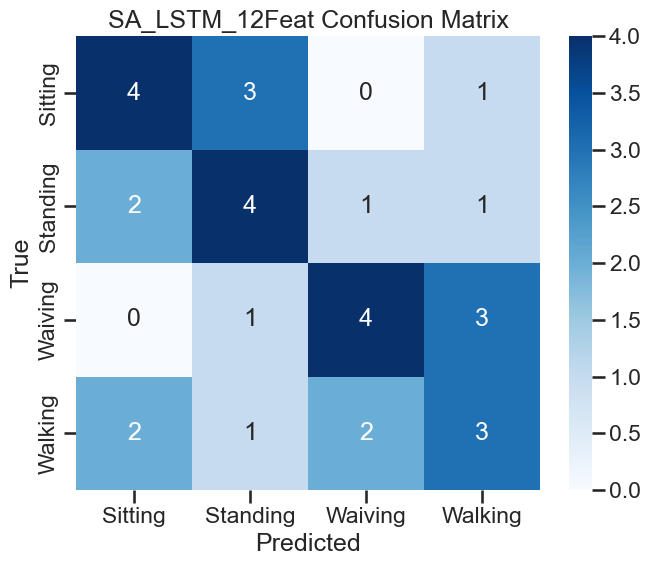


SA_LSTM_12Feat Classification Report
              precision    recall  f1-score   support

     Sitting     0.5000    0.5000    0.5000         8
    Standing     0.4444    0.5000    0.4706         8
     Waiving     0.5714    0.5000    0.5333         8
     Walking     0.3750    0.3750    0.3750         8

    accuracy                         0.4688        32
   macro avg     0.4727    0.4688    0.4697        32
weighted avg     0.4727    0.4688    0.4697        32



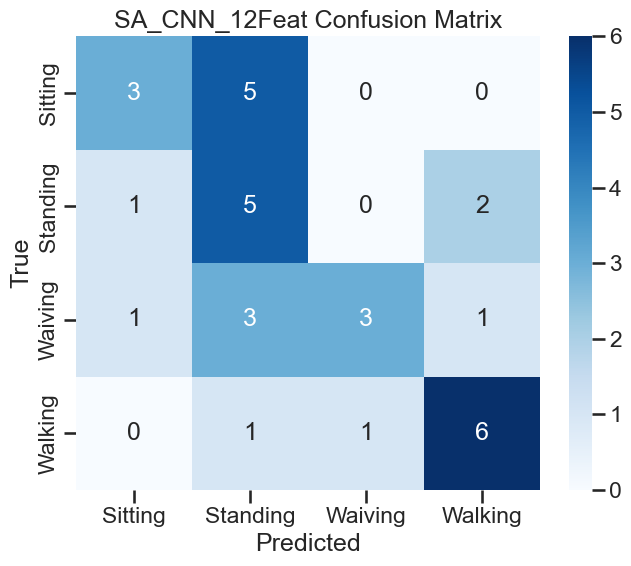


SA_CNN_12Feat Classification Report
              precision    recall  f1-score   support

     Sitting     0.6000    0.3750    0.4615         8
    Standing     0.3571    0.6250    0.4545         8
     Waiving     0.7500    0.3750    0.5000         8
     Walking     0.6667    0.7500    0.7059         8

    accuracy                         0.5312        32
   macro avg     0.5935    0.5312    0.5305        32
weighted avg     0.5935    0.5312    0.5305        32


Single Activity Results (sorted by Macro-F1):


,Model,Accuracy,Macro-F1,Weighted-F1
0,SA_CNN_12Feat,0.5312,0.5305,0.5305
1,SA_LSTM_12Feat,0.4688,0.4697,0.4697


In [46]:
# Single Activity preprocessing + 12-feature vectorization + CNN/LSTM training

SA_WINDOW_LEN = 32
SA_WINDOWS_PER_SAMPLE = 4
SA_CNN_HW = (64, 64)


def extract_12_features(spec_win: np.ndarray, pc_scalar: float, noise_scalar: float) -> np.ndarray:
    """
    Build 12 important features per timestep from a [T, D] spectrogram window.
    Returns [T, 12].
    """
    doppler_bins = np.arange(spec_win.shape[1], dtype=np.float32)
    energy_t = np.sum(spec_win, axis=1) + 1e-9

    # 1) Velocity centroid
    vel = np.sum(spec_win * doppler_bins[None, :], axis=1) / energy_t

    # 2) Velocity spread (weighted variance)
    var = np.sum(((doppler_bins[None, :] - vel[:, None]) ** 2) * spec_win, axis=1) / energy_t
    vel_spread = np.sqrt(np.clip(var, 0.0, None))

    # 3) Total spectral energy
    total_energy = energy_t

    # 4-6) Low / Mid / High Doppler band energies
    bands = np.array_split(np.arange(spec_win.shape[1]), 3)
    low_e = np.mean(spec_win[:, bands[0]], axis=1)
    mid_e = np.mean(spec_win[:, bands[1]], axis=1)
    high_e = np.mean(spec_win[:, bands[2]], axis=1)

    # 7) Temporal derivative magnitude
    dt = np.diff(spec_win, axis=0, prepend=spec_win[0:1])
    dt_mag = np.sqrt(np.sum(dt ** 2, axis=1))

    # 8) Spectral entropy
    entropy = -np.sum((spec_win + 1e-9) * np.log(spec_win + 1e-9), axis=1)

    # 9) Peak amplitude per frame
    peak_amp = np.max(spec_win, axis=1)

    # 10) Mean amplitude per frame
    mean_amp = np.mean(spec_win, axis=1)

    # 11) Points cloud density/quality scalar (repeated over time)
    pc_feat = np.full(spec_win.shape[0], pc_scalar, dtype=np.float32)

    # 12) Noise/SNR scalar (repeated over time)
    noise_feat = np.full(spec_win.shape[0], noise_scalar, dtype=np.float32)

    feat = np.stack(
        [vel, vel_spread, total_energy, low_e, mid_e, high_e, dt_mag, entropy, peak_amp, mean_amp, pc_feat, noise_feat],
        axis=1,
    ).astype(np.float32)

    return feat


def normalize_feature_sequence(seq_2d: np.ndarray) -> np.ndarray:
    mu = seq_2d.mean(axis=0, keepdims=True)
    sd = seq_2d.std(axis=0, keepdims=True)
    return ((seq_2d - mu) / (sd + 1e-6)).astype(np.float32)


sa_x_lstm, sa_x_cnn, sa_y, sa_trace = [], [], [], []
skipped_sa = []

for _, row in sa_split_meta.iterrows():
    rd_csv = Path(row["range_doppler_csv"])
    pc_csv = Path(row["points_cloud_csv"])
    ns_csv = Path(row["noise_snr_csv"])

    df = read_longform(rd_csv)
    if df.empty or df["frame_number"].nunique() == 0:
        skipped_sa.append(str(rd_csv))
        continue

    try:
        cube = dataframe_to_cube(df)
    except Exception:
        skipped_sa.append(str(rd_csv))
        continue

    if cube.size == 0 or cube.shape[0] == 0:
        skipped_sa.append(str(rd_csv))
        continue

    # Playback-style preprocessing
    cube = filter_anomalous_cube(cube)
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)
    spec_td = rd_frames.sum(axis=1)
    spec_td = normalize_spectrogram(spec_td)
    spec_td = fix_sequence_len(spec_td, SEQ_LEN)

    # Optional CSVs as sample-level context features
    pc_vals = safe_numeric_values(pc_csv)
    ns_vals = safe_numeric_values(ns_csv)
    pc_scalar = float(np.nanmean(pc_vals)) if pc_vals.size else 0.0
    noise_scalar = float(np.nanmean(ns_vals)) if ns_vals.size else 0.0

    # Normalize optional scalars to manageable range
    pc_scalar = np.tanh(pc_scalar / 1000.0)
    noise_scalar = np.tanh(noise_scalar / 100.0)

    spec_windows = make_windows(spec_td, SA_WINDOW_LEN, SA_WINDOWS_PER_SAMPLE)

    for w in spec_windows:
        feat_12 = extract_12_features(w, pc_scalar, noise_scalar)   # [32, 12]
        feat_12 = normalize_feature_sequence(feat_12)

        # LSTM input: sequence features
        sa_x_lstm.append(feat_12.astype(np.float32))

        # CNN input: imageized feature map
        cnn_map = resize_2d(feat_12, out_hw=SA_CNN_HW)[..., None]    # [64, 64, 1]
        sa_x_cnn.append(cnn_map.astype(np.float32))

        sa_y.append(sa_label_to_idx[row["activity"]])
        sa_trace.append(row["split"])

sa_x_lstm = np.array(sa_x_lstm, dtype=np.float32)
sa_x_cnn = np.array(sa_x_cnn, dtype=np.float32)
sa_y = np.array(sa_y, dtype=np.int32)
sa_trace = np.array(sa_trace)

if sa_x_lstm.shape[0] == 0:
    raise RuntimeError("No valid single-activity windows created. Check CSV quality.")

sa_train_mask = sa_trace == "train"
sa_test_mask = sa_trace == "test"

x_train_sa_lstm, x_test_sa_lstm = sa_x_lstm[sa_train_mask], sa_x_lstm[sa_test_mask]
x_train_sa_cnn, x_test_sa_cnn = sa_x_cnn[sa_train_mask], sa_x_cnn[sa_test_mask]
y_train_sa, y_test_sa = sa_y[sa_train_mask], sa_y[sa_test_mask]

print("Built single-activity tensors:")
print("LSTM train/test:", x_train_sa_lstm.shape, x_test_sa_lstm.shape)
print("CNN  train/test:", x_train_sa_cnn.shape, x_test_sa_cnn.shape)
print("y train/test:", y_train_sa.shape, y_test_sa.shape)
if skipped_sa:
    print("Skipped malformed sessions:", len(skipped_sa))


# Models

def build_sa_lstm(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25)),
        layers.Bidirectional(layers.LSTM(32, dropout=0.2)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_sa_cnn(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def train_sa_model(model, x_train, y_train, x_val, y_val, epochs=90, batch_size=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    cls = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=cls, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(cls, weights)}

    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ]

    return model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        class_weight=class_weight,
        callbacks=cb,
    )


def eval_sa_model(model, x_test, y_test, labels, title):
    prob = model.predict(x_test, verbose=0)
    pred = np.argmax(prob, axis=1)

    acc = accuracy_score(y_test, pred)
    macro = f1_score(y_test, pred, average="macro")
    weighted = f1_score(y_test, pred, average="weighted")

    cm = confusion_matrix(y_test, pred, labels=np.arange(len(labels)))
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(f"\n{title} Classification Report")
    print(classification_report(y_test, pred, target_names=labels, digits=4))

    return {"Model": title, "Accuracy": acc, "Macro-F1": macro, "Weighted-F1": weighted}


sa_labels = SA_ACTIVITIES
n_sa_classes = len(sa_labels)

sa_lstm_model = build_sa_lstm(x_train_sa_lstm.shape[1:], n_sa_classes)
sa_cnn_model = build_sa_cnn(x_train_sa_cnn.shape[1:], n_sa_classes)

print("\nTraining LSTM on 12-feature sequences...")
sa_lstm_hist = train_sa_model(sa_lstm_model, x_train_sa_lstm, y_train_sa, x_test_sa_lstm, y_test_sa, epochs=90, batch_size=8)

print("\nTraining CNN on imageized 12-feature maps...")
sa_cnn_hist = train_sa_model(sa_cnn_model, x_train_sa_cnn, y_train_sa, x_test_sa_cnn, y_test_sa, epochs=90, batch_size=8)

sa_results = []
sa_results.append(eval_sa_model(sa_lstm_model, x_test_sa_lstm, y_test_sa, sa_labels, "SA_LSTM_12Feat"))
sa_results.append(eval_sa_model(sa_cnn_model, x_test_sa_cnn, y_test_sa, sa_labels, "SA_CNN_12Feat"))

sa_results_df = pd.DataFrame(sa_results).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print("\nSingle Activity Results (sorted by Macro-F1):")
display(sa_results_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))


In [49]:
# Summary cell: preprocessing, feature vectorization, model preparation, and results

best_sa = sa_results_df.iloc[0]

print("=" * 90)
print("SINGLE ACTIVITY SUMMARY: PREPROCESSING, FEATURE VECTOR, MODELING, AND RESULTS")
print("=" * 90)

print("\n1) Data Source and Split")
print("- Dataset: Research Data/Single Activity Data")
print("- Activities:", ", ".join(SA_ACTIVITIES))
print("- Split strategy: sample-level 60% train / 40% test per activity")
print("- All sessions with range_doppler.csv are used; points_cloud/noise_snr are used when present")

print("\n2) Preprocessing Steps")
print("- Range-Doppler frame anomaly filtering (saturation/outlier frame removal)")
print("- FFT-shift + resize + playback-style normalization")
print("- Clutter suppression and log-compression via normalize_spectrogram")
print("- Sequence length normalization to fixed temporal length")
print("- Windowing into fixed training segments")

print("\n3) 12 Most Important Features Used")
feature_names = [
    "1. Velocity centroid",
    "2. Velocity spread",
    "3. Total spectral energy",
    "4. Low-band energy",
    "5. Mid-band energy",
    "6. High-band energy",
    "7. Temporal derivative magnitude",
    "8. Spectral entropy",
    "9. Peak amplitude",
    "10. Mean amplitude",
    "11. Points-cloud scalar context",
    "12. Noise/SNR scalar context",
]
for f in feature_names:
    print("-", f)

print("\n4) Why These Features")
print("- Velocity + spread separate static vs moving activities")
print("- Multi-band energies capture where Doppler power concentrates")
print("- Temporal derivative captures motion dynamics")
print("- Entropy captures signal complexity")
print("- Peak/mean amplitudes measure intensity level")
print("- points_cloud/noise_snr add session context and data-quality cues")

print("\n5) Model Preparation")
print("- LSTM model: sequence learning on [T, 12] features")
print("- CNN model: 2D learning on resized feature map image")
print("- Class-weighted loss for balanced learning")
print("- Early stopping + LR reduction to avoid overfitting")

print("\n6) Final Results")
display(sa_results_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))
print(f"Best model: {best_sa['Model']}")
print(f"Best Accuracy: {best_sa['Accuracy']:.4f}")
print(f"Best Macro-F1: {best_sa['Macro-F1']:.4f}")
print(f"Best Weighted-F1: {best_sa['Weighted-F1']:.4f}")


SINGLE ACTIVITY SUMMARY: PREPROCESSING, FEATURE VECTOR, MODELING, AND RESULTS

1) Data Source and Split
- Dataset: Research Data/Single Activity Data
- Activities: Sitting, Standing, Waiving, Walking
- Split strategy: sample-level 60% train / 40% test per activity
- All sessions with range_doppler.csv are used; points_cloud/noise_snr are used when present

2) Preprocessing Steps
- Range-Doppler frame anomaly filtering (saturation/outlier frame removal)
- FFT-shift + resize + playback-style normalization
- Clutter suppression and log-compression via normalize_spectrogram
- Sequence length normalization to fixed temporal length
- Windowing into fixed training segments

3) 12 Most Important Features Used
- 1. Velocity centroid
- 2. Velocity spread
- 3. Total spectral energy
- 4. Low-band energy
- 5. Mid-band energy
- 6. High-band energy
- 7. Temporal derivative magnitude
- 8. Spectral entropy
- 9. Peak amplitude
- 10. Mean amplitude
- 11. Points-cloud scalar context
- 12. Noise/SNR scalar

,Model,Accuracy,Macro-F1,Weighted-F1
0,SA_CNN_12Feat,0.5312,0.5305,0.5305
1,SA_LSTM_12Feat,0.4688,0.4697,0.4697


Best model: SA_CNN_12Feat
Best Accuracy: 0.5312
Best Macro-F1: 0.5305
Best Weighted-F1: 0.5305


## Cell 17: Confusion-Focused Improvement (All CSV + Advanced 12-Feature Vector)

Goal: reduce the two major confusion pairs:
- Standing vs Sitting
- Walking vs Waiving

Strategy:
1. Use **all available CSVs** per session (`range_doppler.csv`, `points_cloud.csv`, `noise_snr.csv`).
2. Build a new **12-feature vector** emphasizing:
   - Range-position features (for Standing vs Sitting)
   - Periodicity and temporal dynamics (for Walking vs Waiving)
3. Train both **LSTM** and **CNN** again and compare against previous single-activity results.


Improved tensors:
LSTM train/test: (48, 32, 12) (32, 32, 12)
CNN  train/test: (48, 64, 64, 1) (32, 64, 64, 1)

Training improved LSTM...
Epoch 1/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.1851 - loss: 1.3958 - val_accuracy: 0.3750 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 2/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2747 - loss: 1.3634 - val_accuracy: 0.3750 - val_loss: 1.3684 - learning_rate: 0.0010
Epoch 3/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3452 - loss: 1.3499 - val_accuracy: 0.4062 - val_loss: 1.3622 - learning_rate: 0.0010
Epoch 4/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5250 - loss: 1.2973 - val_accuracy: 0.3438 - val_loss: 1.3605 - learning_rate: 0.0010
Epoch 5/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3765 - loss: 1.2655 - val_accuracy: 0.3125 - val_loss: 1.3605 - learning_rate: 0.0010
Epoch 6/110
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4842 - loss: 1.2753 - val_accuracy: 0.2500 - val

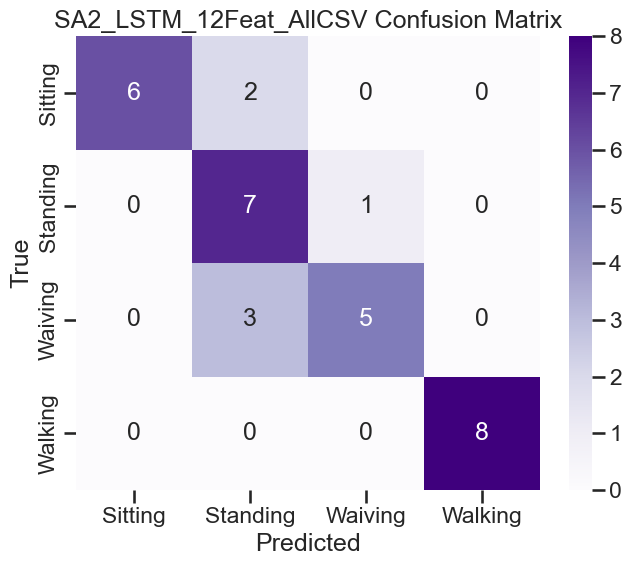


SA2_LSTM_12Feat_AllCSV Classification Report
              precision    recall  f1-score   support

     Sitting     1.0000    0.7500    0.8571         8
    Standing     0.5833    0.8750    0.7000         8
     Waiving     0.8333    0.6250    0.7143         8
     Walking     1.0000    1.0000    1.0000         8

    accuracy                         0.8125        32
   macro avg     0.8542    0.8125    0.8179        32
weighted avg     0.8542    0.8125    0.8179        32



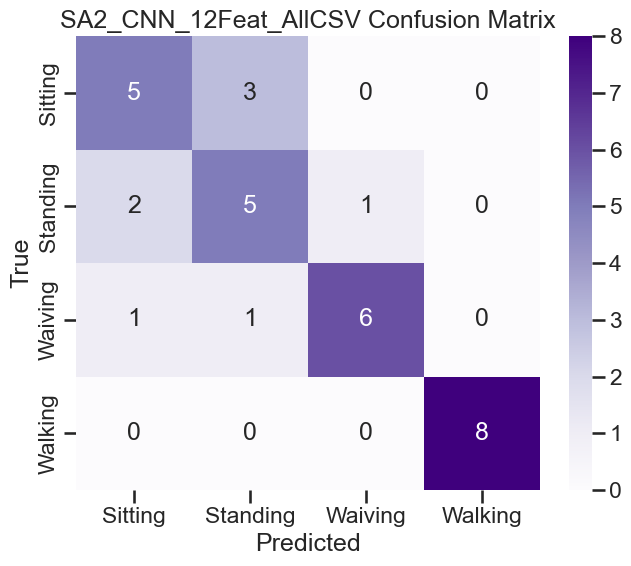


SA2_CNN_12Feat_AllCSV Classification Report
              precision    recall  f1-score   support

     Sitting     0.6250    0.6250    0.6250         8
    Standing     0.5556    0.6250    0.5882         8
     Waiving     0.8571    0.7500    0.8000         8
     Walking     1.0000    1.0000    1.0000         8

    accuracy                         0.7500        32
   macro avg     0.7594    0.7500    0.7533        32
weighted avg     0.7594    0.7500    0.7533        32


Improved Single Activity Results:


,Model,Accuracy,Macro-F1,Weighted-F1
0,SA2_LSTM_12Feat_AllCSV,0.8125,0.8179,0.8179
1,SA2_CNN_12Feat_AllCSV,0.7500,0.7533,0.7533



Comparison vs previous feature-vectorization block:
Previous best: SA_CNN_12Feat | Acc=0.5312, Macro-F1=0.5305
Improved best: SA2_LSTM_12Feat_AllCSV | Acc=0.8125, Macro-F1=0.8179

Confusion pair counts on improved best model:
Standing <-> Sitting confusions: 2
Walking <-> Waiving confusions: 0


In [51]:
# Improved feature-vectorization using all CSVs, targeting confusion pairs

SA2_WINDOW_LEN = 32
SA2_WINDOWS_PER_SAMPLE = 4
SA2_CNN_HW = (64, 64)


def robust_stats(vals: np.ndarray) -> tuple[float, float, float, float]:
    if vals.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    q1, q3 = np.percentile(vals, [25, 75])
    return float(np.mean(vals)), float(np.std(vals)), float(q1), float(q3)


def periodicity_score_1d(x: np.ndarray) -> float:
    """Simple periodicity from normalized auto-correlation peak in lag range [2, 10]."""
    if len(x) < 12:
        return 0.0
    x = x - np.mean(x)
    denom = np.linalg.norm(x) + 1e-9
    x = x / denom
    ac = np.correlate(x, x, mode="full")[len(x)-1:]
    ac = ac / (ac[0] + 1e-9)
    lo, hi = 2, min(10, len(ac)-1)
    if hi <= lo:
        return 0.0
    return float(np.max(ac[lo:hi+1]))


def extract_12_features_confusion_target(rd_win: np.ndarray, pc_ctx: tuple[float, float], ns_ctx: tuple[float, float]) -> np.ndarray:
    """
    rd_win: [T, H, W] range-doppler window
    Returns [T, 12] sequence features.
    """
    # Profiles
    doppler_prof = rd_win.sum(axis=1)  # [T, W]
    range_prof = rd_win.sum(axis=2)    # [T, H]

    doppler_bins = np.arange(doppler_prof.shape[1], dtype=np.float32)
    range_bins = np.arange(range_prof.shape[1], dtype=np.float32)

    d_energy = np.sum(doppler_prof, axis=1) + 1e-9
    r_energy = np.sum(range_prof, axis=1) + 1e-9

    # 1) Doppler centroid (velocity proxy)
    d_cent = np.sum(doppler_prof * doppler_bins[None, :], axis=1) / d_energy

    # 2) Doppler spread
    d_var = np.sum(((doppler_bins[None, :] - d_cent[:, None]) ** 2) * doppler_prof, axis=1) / d_energy
    d_spread = np.sqrt(np.clip(d_var, 0.0, None))

    # 3) Range centroid (Standing vs Sitting discriminator)
    r_cent = np.sum(range_prof * range_bins[None, :], axis=1) / r_energy

    # 4) Range spread (body extent proxy)
    r_var = np.sum(((range_bins[None, :] - r_cent[:, None]) ** 2) * range_prof, axis=1) / r_energy
    r_spread = np.sqrt(np.clip(r_var, 0.0, None))

    # 5) Total energy
    total_e = d_energy

    # 6) Temporal derivative magnitude
    dt = np.diff(doppler_prof, axis=0, prepend=doppler_prof[0:1])
    dt_mag = np.sqrt(np.sum(dt ** 2, axis=1))

    # 7) Spectral entropy over Doppler
    p = doppler_prof / d_energy[:, None]
    entropy = -np.sum((p + 1e-9) * np.log(p + 1e-9), axis=1)

    # 8) Periodicity score (Walking tends to be more periodic)
    per = periodicity_score_1d(d_cent)
    per_feat = np.full(rd_win.shape[0], per, dtype=np.float32)

    # Context from points cloud and noise/snr (all csv usage)
    pc_mean, pc_iqr = pc_ctx
    ns_mean, ns_iqr = ns_ctx

    # 9) points_cloud mean
    pc_mean_feat = np.full(rd_win.shape[0], pc_mean, dtype=np.float32)

    # 10) points_cloud IQR
    pc_iqr_feat = np.full(rd_win.shape[0], pc_iqr, dtype=np.float32)

    # 11) noise_snr mean
    ns_mean_feat = np.full(rd_win.shape[0], ns_mean, dtype=np.float32)

    # 12) noise_snr IQR
    ns_iqr_feat = np.full(rd_win.shape[0], ns_iqr, dtype=np.float32)

    feat = np.stack(
        [d_cent, d_spread, r_cent, r_spread, total_e, dt_mag, entropy, per_feat, pc_mean_feat, pc_iqr_feat, ns_mean_feat, ns_iqr_feat],
        axis=1,
    ).astype(np.float32)
    return feat


def zscore_seq(x: np.ndarray) -> np.ndarray:
    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True)
    return ((x - mu) / (sd + 1e-6)).astype(np.float32)


sa2_x_lstm, sa2_x_cnn, sa2_y, sa2_trace = [], [], [], []
skipped_sa2 = []

for _, row in sa_split_meta.iterrows():
    rd_csv = Path(row["range_doppler_csv"])
    pc_csv = Path(row["points_cloud_csv"])
    ns_csv = Path(row["noise_snr_csv"])

    df = read_longform(rd_csv)
    if df.empty or df["frame_number"].nunique() == 0:
        skipped_sa2.append(str(rd_csv))
        continue

    try:
        cube = dataframe_to_cube(df)
    except Exception:
        skipped_sa2.append(str(rd_csv))
        continue

    if cube.size == 0 or cube.shape[0] == 0:
        skipped_sa2.append(str(rd_csv))
        continue

    cube = filter_anomalous_cube(cube)
    rd_frames = np.stack([playback_like_process_frame(f, out_hw=SPATIAL_SIZE) for f in cube], axis=0)  # [T,64,64]
    rd_frames = fix_sequence_len(rd_frames, SEQ_LEN)  # keep range info for r_cent/r_spread

    # Context features from all CSVs
    pc_vals = safe_numeric_values(pc_csv)
    ns_vals = safe_numeric_values(ns_csv)
    pc_m, pc_s, pc_q1, pc_q3 = robust_stats(pc_vals)
    ns_m, ns_s, ns_q1, ns_q3 = robust_stats(ns_vals)

    pc_iqr = pc_q3 - pc_q1
    ns_iqr = ns_q3 - ns_q1

    # squash to stable range
    pc_ctx = (float(np.tanh(pc_m / 1000.0)), float(np.tanh(pc_iqr / 1000.0)))
    ns_ctx = (float(np.tanh(ns_m / 100.0)), float(np.tanh(ns_iqr / 100.0)))

    rd_windows = make_windows(rd_frames, SA2_WINDOW_LEN, SA2_WINDOWS_PER_SAMPLE)  # [Nw, 32, 64, 64]

    for rw in rd_windows:
        feat12 = extract_12_features_confusion_target(rw, pc_ctx, ns_ctx)  # [32,12]
        feat12 = zscore_seq(feat12)

        sa2_x_lstm.append(feat12.astype(np.float32))
        sa2_x_cnn.append(resize_2d(feat12, out_hw=SA2_CNN_HW)[..., None].astype(np.float32))
        sa2_y.append(sa_label_to_idx[row["activity"]])
        sa2_trace.append(row["split"])

sa2_x_lstm = np.array(sa2_x_lstm, dtype=np.float32)
sa2_x_cnn = np.array(sa2_x_cnn, dtype=np.float32)
sa2_y = np.array(sa2_y, dtype=np.int32)
sa2_trace = np.array(sa2_trace)

if len(sa2_x_lstm) == 0:
    raise RuntimeError("No valid windows for confusion-focused pipeline.")

m_train = sa2_trace == "train"
m_test = sa2_trace == "test"

x_train_sa2_lstm, x_test_sa2_lstm = sa2_x_lstm[m_train], sa2_x_lstm[m_test]
x_train_sa2_cnn, x_test_sa2_cnn = sa2_x_cnn[m_train], sa2_x_cnn[m_test]
y_train_sa2, y_test_sa2 = sa2_y[m_train], sa2_y[m_test]

print("Improved tensors:")
print("LSTM train/test:", x_train_sa2_lstm.shape, x_test_sa2_lstm.shape)
print("CNN  train/test:", x_train_sa2_cnn.shape, x_test_sa2_cnn.shape)
if skipped_sa2:
    print("Skipped malformed sessions:", len(skipped_sa2))


def build_sa2_lstm(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(96, return_sequences=True, dropout=0.3)),
        layers.Bidirectional(layers.LSTM(48, dropout=0.25)),
        layers.Dense(96, activation="relu"),
        layers.Dropout(0.35),
        layers.Dense(48, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax"),
    ])


def build_sa2_cnn(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(24, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(48, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(96, (3, 3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.35),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])


def train_sa2(model, xtr, ytr, xva, yva, epochs=110, batch=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    cls = np.unique(ytr)
    w = compute_class_weight(class_weight="balanced", classes=cls, y=ytr)
    cw = {int(c): float(v) for c, v in zip(cls, w)}
    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=14, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
    ]
    return model.fit(xtr, ytr, validation_data=(xva, yva), epochs=epochs, batch_size=batch, verbose=1, class_weight=cw, callbacks=cb)


def evaluate_sa2(model, xte, yte, labels, title):
    prob = model.predict(xte, verbose=0)
    pred = np.argmax(prob, axis=1)
    acc = accuracy_score(yte, pred)
    macro = f1_score(yte, pred, average="macro")
    weighted = f1_score(yte, pred, average="weighted")
    cm = confusion_matrix(yte, pred, labels=np.arange(len(labels)))

    plt.figure(figsize=(7, 6))
    sns.heatmap(pd.DataFrame(cm, index=labels, columns=labels), annot=True, fmt="d", cmap="Purples")
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(f"\n{title} Classification Report")
    print(classification_report(yte, pred, target_names=labels, digits=4))
    return {"Model": title, "Accuracy": acc, "Macro-F1": macro, "Weighted-F1": weighted, "CM": cm}


labels_sa2 = SA_ACTIVITIES
ncls = len(labels_sa2)

sa2_lstm = build_sa2_lstm(x_train_sa2_lstm.shape[1:], ncls)
sa2_cnn = build_sa2_cnn(x_train_sa2_cnn.shape[1:], ncls)

print("\nTraining improved LSTM...")
_ = train_sa2(sa2_lstm, x_train_sa2_lstm, y_train_sa2, x_test_sa2_lstm, y_test_sa2, epochs=110, batch=8)

print("\nTraining improved CNN...")
_ = train_sa2(sa2_cnn, x_train_sa2_cnn, y_train_sa2, x_test_sa2_cnn, y_test_sa2, epochs=110, batch=8)

res_sa2_lstm = evaluate_sa2(sa2_lstm, x_test_sa2_lstm, y_test_sa2, labels_sa2, "SA2_LSTM_12Feat_AllCSV")
res_sa2_cnn = evaluate_sa2(sa2_cnn, x_test_sa2_cnn, y_test_sa2, labels_sa2, "SA2_CNN_12Feat_AllCSV")

improved_df = pd.DataFrame([
    {k: v for k, v in res_sa2_lstm.items() if k != "CM"},
    {k: v for k, v in res_sa2_cnn.items() if k != "CM"},
]).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print("\nImproved Single Activity Results:")
display(improved_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))

# Compare against previous best result from sa_results_df
prev_best = sa_results_df.iloc[0]
new_best = improved_df.iloc[0]
print("\nComparison vs previous feature-vectorization block:")
print(f"Previous best: {prev_best['Model']} | Acc={prev_best['Accuracy']:.4f}, Macro-F1={prev_best['Macro-F1']:.4f}")
print(f"Improved best: {new_best['Model']} | Acc={new_best['Accuracy']:.4f}, Macro-F1={new_best['Macro-F1']:.4f}")

# Pairwise confusion diagnostics (Standing/Sitting and Walking/Waiving)
label_to_i = {l: i for i, l in enumerate(labels_sa2)}
cm_best = res_sa2_lstm["CM"] if res_sa2_lstm["Macro-F1"] >= res_sa2_cnn["Macro-F1"] else res_sa2_cnn["CM"]

ss = cm_best[label_to_i["Standing"], label_to_i["Sitting"]] + cm_best[label_to_i["Sitting"], label_to_i["Standing"]]
ww = cm_best[label_to_i["Walking"], label_to_i["Waiving"]] + cm_best[label_to_i["Waiving"], label_to_i["Walking"]]
print(f"\nConfusion pair counts on improved best model:")
print(f"Standing <-> Sitting confusions: {int(ss)}")
print(f"Walking <-> Waiving confusions: {int(ww)}")